<h1 style="color:#6c63ff; font-weight:bold;">Gym Data Modeling</p>

<h2 style="color:#6c63ff; border-bottom:2px solid #6c63ff; padding-bottom:5px;">Index</h2>


<style>
a { color: #6c63ff !important; }
</style>

<div style="padding: 10px 0; color:#6c63ff;">

**6. Imports**
<br>&nbsp;&nbsp;&nbsp;&nbsp;[6.1 Libraries Imports](#imports)
<br>&nbsp;&nbsp;&nbsp;&nbsp;[6.2 Gym Data Importation](#gym-data)


**7. Clustering**
<br>&nbsp;&nbsp;&nbsp;&nbsp;[7.1 Elbow ](#elbow)
<br>&nbsp;&nbsp;&nbsp;&nbsp;[7.2 Silhouette ](#silhouette)
<br>&nbsp;&nbsp;&nbsp;&nbsp;[7.3 K-Means ](#kmeans)
<br>&nbsp;&nbsp;&nbsp;&nbsp;[7.4 Hierarchical Clustering ](#hclustering)
<br>&nbsp;&nbsp;&nbsp;&nbsp;[7.5 Self Organizing Map](#som)
<br>&nbsp;&nbsp;&nbsp;&nbsp;[7.6 Comparing Algorithms ](#comparing-algorithms)

**8. Cluster Analysis**
<br>&nbsp;&nbsp;&nbsp;&nbsp;[8.1 Cluster Creation ](#clucreation)
<br>&nbsp;&nbsp;&nbsp;&nbsp;[8.2 Cluster Visualization](#cluview)

**9. Conclusions**
<br>&nbsp;&nbsp;&nbsp;&nbsp;[9.1 Summary of Findings ](#fisuma)
<br>&nbsp;&nbsp;&nbsp;&nbsp;[9.2 Business Recommendations](#bureco)


</div>

<h2 id = "imports" style="color:#6c63ff; border-bottom:2px solid #6c63ff; padding-bottom:5px;">6. Imports</h2>

<h3 style="color:#6c63ff; padding-bottom:5px;">Libraries Imports</h3>

In [102]:
#!pip install minisom

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from minisom import MiniSom
import matplotlib.pyplot as plt
import seaborn as sns

<h3 style="color:#6c63ff; padding-bottom:5px;">Gym Data Importation</h3>

In [104]:
df = pd.read_csv('data_cluster.csv')
df_analysis = pd.read_csv('data_analysis.csv')

<h2 id = "imports" style="color:#6c63ff; border-bottom:2px solid #6c63ff; padding-bottom:5px;">7. Scaling</h2>

In [105]:
scaler = StandardScaler()

df_scaled_array = scaler.fit_transform(df)

df_scaled = pd.DataFrame(df_scaled_array, columns=df.columns)

print(df_scaled.describe().round(2).loc[['mean', 'std']])
df_scaled.head()

      Age  visit_per_week  weekend_ratio  avg_time_in_gym  \
mean  0.0             0.0            0.0             -0.0   
std   1.0             1.0            1.0              1.0   

      num_classes_attended  ratio_cardio  ratio_strength  ratio_mind_body  \
mean                   0.0          -0.0            -0.0             -0.0   
std                    1.0           1.0             1.0              1.0   

      sauna_session_impact  
mean                   0.0  
std                    1.0  


,Age,visit_per_week,weekend_ratio,avg_time_in_gym,num_classes_attended,ratio_cardio,ratio_strength,ratio_mind_body,sauna_session_impact
0,-0.333316,1.061773,-0.153016,0.246696,1.732276,0.543314,1.834139,-0.489343,1.045893
1,1.516386,0.256179,0.132675,-1.315252,-0.870041,-0.559862,-0.510558,-0.489343,-0.856327
2,0.961476,-1.355009,2.418201,0.407485,-0.002602,-0.559862,3.006488,-0.489343,-0.856327
3,1.238931,0.256179,0.132675,-0.143791,-0.870041,-0.559862,-0.510558,-0.489343,0.767119
4,1.238931,-0.549415,-1.010088,-1.269312,1.732276,1.646491,-0.510558,0.696943,-0.856327


<h2 id = "imports" style="color:#6c63ff; border-bottom:2px solid #6c63ff; padding-bottom:5px;">8. K-Means</h2>

Let's try K-Means by testing from 2 to 20 clusters.

In [106]:
k_range = range(2, 21)

Initializing lists to track scores of each model in Inertia and Silhouette Scores:

In [107]:
inertia_scores = []
silhouette_scores = []

Running the algoritms:

In [108]:
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)
    
    inertia_scores.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, labels))

Plotting the Elbow graph and the Silhoutte Scores.

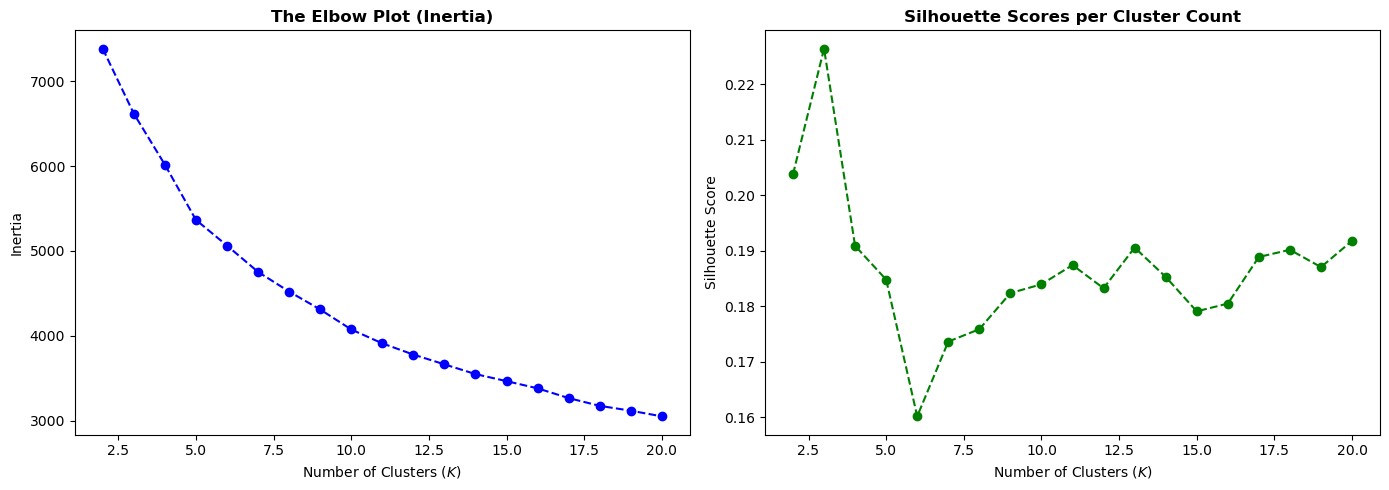

In [109]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, inertia_scores, marker='o', color='blue', linestyle='--')
ax1.set_title("The Elbow Plot (Inertia)", fontsize=12, weight='bold')
ax1.set_xlabel("Number of Clusters ($K$)")
ax1.set_ylabel("Inertia")

ax2.plot(k_range, silhouette_scores, marker='o', color='green', linestyle='--')
ax2.set_title("Silhouette Scores per Cluster Count", fontsize=12, weight='bold')
ax2.set_xlabel("Number of Clusters ($K$)")
ax2.set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

This means that we should adopt 3 clusters. Clearly 3 clusters has a higher silhouette score.

In [110]:
final_model = KMeans(n_clusters=3, random_state=42, n_init=10)

winning_labels = final_model.fit_predict(df_scaled)

In [111]:
df['Cluster'] = winning_labels

cluster_means = df.groupby('Cluster').mean().reset_index()

melted_df = pd.melt(cluster_means, id_vars='Cluster', var_name='Feature', value_name='Average_Value')

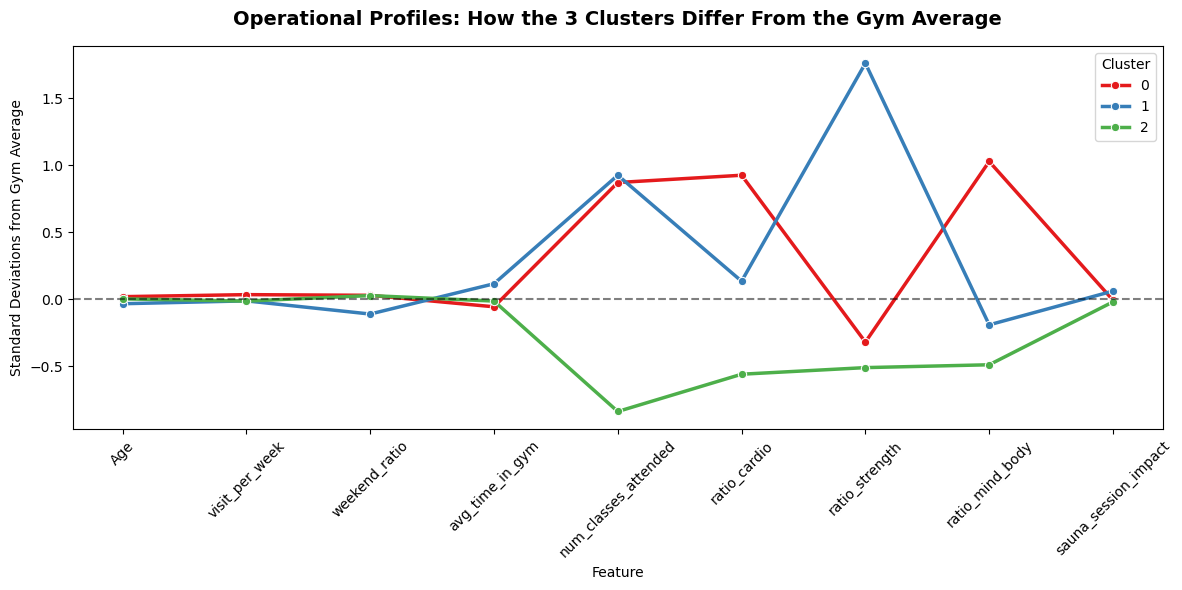

In [113]:
df_scaled['Cluster'] = winning_labels
scaled_means = df_scaled.groupby('Cluster').mean().reset_index()
melted_scaled = pd.melt(scaled_means, id_vars='Cluster', var_name='Feature', value_name='Scaled_Average')

plt.figure(figsize=(12, 6))
sns.lineplot(data=melted_scaled, x='Feature', y='Scaled_Average', hue='Cluster', marker='o', palette='Set1', linewidth=2.5)

plt.axhline(0, color='black', linestyle='--', alpha=0.5) # The overall gym average line
plt.title("Operational Profiles: How the 3 Clusters Differ From the Gym Average", weight='bold', fontsize=14, pad=15)
plt.xticks(rotation=45)
plt.ylabel("Standard Deviations from Gym Average")
plt.tight_layout()
plt.show()

From here, we can see that:
- Cluster 0: the ones going to Cardio and Mind Body classes - tends to visit more times (just slightly)
- Cluster 1: the ones going to Strenght classes - use sauna slightly more, and spend more time on gym, go less on weekends
- Cluster 2: the ones going for free gym (no classes) - classic gym user

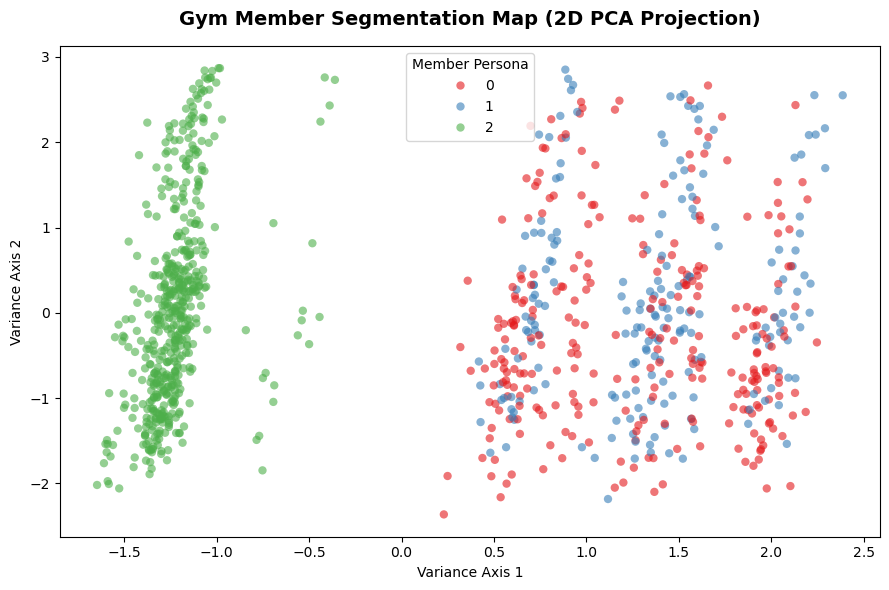

In [114]:
pca_plotter = PCA(n_components=2)
X_pca = pca_plotter.fit_transform(df_scaled.drop(columns=['Cluster']))

df_vis = pd.DataFrame(X_pca, columns=['Principal_Component_1', 'Principal_Component_2'])
df_vis['Cluster'] = winning_labels

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df_vis, 
    x='Principal_Component_1', 
    y='Principal_Component_2', 
    hue='Cluster', 
    palette='Set1', 
    alpha=0.6,
    edgecolor='none'
)

plt.title("Gym Member Segmentation Map (2D PCA Projection)", weight='bold', fontsize=14, pad=15)
plt.xlabel("Variance Axis 1")
plt.ylabel("Variance Axis 2")
plt.legend(title="Member Persona")
plt.tight_layout()
plt.show()

From this PCA Projection, we can see that Cluster 2 is clearly different from the other two, as they don't go to classes at all. Cluster 0 and 1 are very mixed in between each other.

In [116]:
# 1. Load the analysis data and inject the winning labels
df_analysis['Gym_Cluster'] = winning_labels

# 2. Function to automatically print categorical distributions per cluster
def analyze_categorical(column_name):
    print(f"\n=== {column_name.upper()} Distribution by Cluster (%) ===")
    distribution = df_analysis.groupby('Gym_Cluster')[column_name].value_counts(normalize=True).unstack() * 100
    print(distribution.fillna(0).round(1))

# 3. Run the analysis for your key metrics
analyze_categorical('gender')
analyze_categorical('abonoment_type')
analyze_categorical('uses_sauna')
analyze_categorical('fav_drink')


=== GENDER Distribution by Cluster (%) ===
gender       Female  Male
Gym_Cluster              
0              51.6  48.4
1              47.8  52.2
2              50.6  49.4

=== ABONOMENT_TYPE Distribution by Cluster (%) ===
abonoment_type  Premium  Standard
Gym_Cluster                      
0                  46.6      53.4
1                  51.2      48.8
2                  50.0      50.0

=== USES_SAUNA Distribution by Cluster (%) ===
uses_sauna   False  True 
Gym_Cluster              
0             48.8   51.2
1             48.8   51.2
2             52.5   47.5

=== FAV_DRINK Distribution by Cluster (%) ===
fav_drink    berry_boost  berry_boost, black_currant  \
Gym_Cluster                                            
0                    7.9                         2.9   
1                    3.0                         2.0   
2                   10.9                         1.2   

fav_drink    berry_boost, coconut_pineapple  berry_boost, lemon  \
Gym_Cluster                    

<h2 id = "imports" style="color:#6c63ff; border-bottom:2px solid #6c63ff; padding-bottom:5px;">9. Hierarchical</h2>

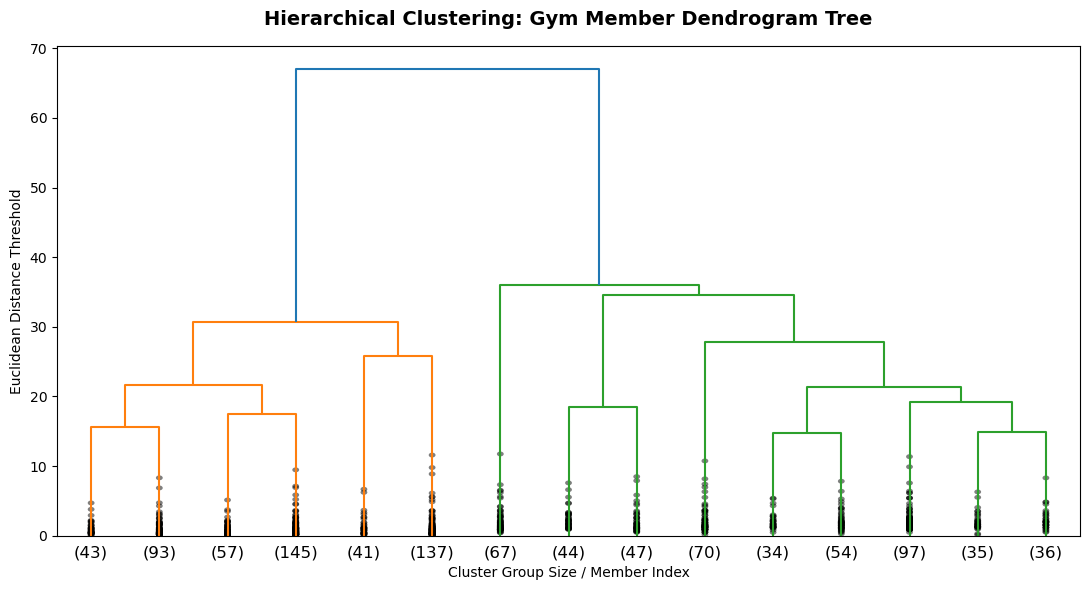

In [118]:
from scipy.cluster.hierarchy import dendrogram, linkage
# 2. Compute the linkage matrix using Ward's method 
# (Ward's method minimizes the variance within the clusters as they merge)
linked = linkage(df_scaled, method="ward")

# 3. Plot the Dendrogram Tree
plt.figure(figsize=(11, 6))
dendrogram(
    linked,
    truncate_mode="lastp",
    p=15,  # Collapses the tree to show just the final 15 main branch merges
    show_contracted=True,
)

plt.title("Hierarchical Clustering: Gym Member Dendrogram Tree", weight="bold", fontsize=14, pad=15)
plt.xlabel("Cluster Group Size / Member Index")
plt.ylabel("Euclidean Distance Threshold")
plt.tight_layout()
plt.show()

In [121]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

# 1. Initialize and fit the 3-cluster model on your scaled data
hierarchical = AgglomerativeClustering(n_clusters=3, metric="euclidean", linkage="ward")
hc_labels = hierarchical.fit_predict(df_scaled)

# 2. Check the mathematical strength of this model
hc_silhouette = silhouette_score(df_scaled, hc_labels)
print(f"Hierarchical Clustering Silhouette Score: {hc_silhouette:.4f}")
km_silhouette = silhouette_score(df_scaled, winning_labels)

print("=== K-Means Performance Metric ===")
print(f"K-Means Silhouette Score (K=3): {km_silhouette:.4f}")

Hierarchical Clustering Silhouette Score: 0.2591
=== K-Means Performance Metric ===
K-Means Silhouette Score (K=3): 0.2544
